# Last week

- Static household problem (households choose consumption and labor supply)
- Production economy with Cobb-Douglas technology
- General equilibrium:
    - Find optimal household and firm choices
    - Find equilibrium prices (wage and rental rate of capital)

# This week

- Households live for 2 periods (young and old)
- Households choose consumption and savings (dynamic problem)
- Production economy with Cobb-Douglas technology (unchanged)
- General equilibrium:
    - Steady state equilibrium (quantities and prices do not change over time)
    - Transition dynamics (response to shocks)

***
# Overlapping-generations model (OLG)

## Steady-state equilibrium


### Household problem ($N$ identical households)

- Two types of households alive in any period: **young** ($y$) and **old** ($o$)
- Households choose consumption $(c_y, c_o)$ and savings $a$:
    $$
    \begin{aligned}
    \max_{c_y,~c_o,~a} \enskip & \Bigl\{ u(c_y) + \beta u(c_o) \Bigr\} \\
    \text{s.t.} \quad c_y + a &= w \\
                    c_o &= (1+r)a \\
        c_y &\geq 0, ~ c_o \geq 0,~ a \geq 0
    \end{aligned}
    $$

-   Each household inelastically supplies 1 unit of labor when young (no optimization!)
-   Flow utility:
    $$
    u(c) = \begin{cases}
        \frac{c^{1-\gamma}}{1-\gamma} & \text{if } \gamma \neq 1 \\
        \log(c) & \text{if } \gamma = 1
        \end{cases}
    $$

-   Choice variables:

    -   $c_y$:  Consumption when young
    -   $c_o$:  Consumption when old
    -   $a$:    Savings when young

- Parameters:

    -   $\beta$: Discount factor
    -   $\gamma$: Relative risk aversion

- Prices (taken as given, competitive equilibrium):

    -   $r$: Interest rate (return on capital)
    -   $w$: Wage rate


#### Analytical solution

-   Optimal **savings rate** of the young:
    <a id='olg-hh-srate'></a>
    $$
    \tag{2}
    s = \left[1 + \beta^{-\frac{1}{\gamma}} (1+r)^{1-\frac{1}{\gamma}}\right]^{-1}
    $$
- Optimal **savings** of the young (from budget constraint):
    $$
    a = s \cdot w
    $$

***
### Firm problem (representative firm)

- Firm problem:
    $$
    \max_{K,~L} \enskip \Pi = 
        \underbrace{z K^{\alpha} L^{1-\alpha}}_{\text{Output } Y}
         - \underbrace{(r + \delta) K}_{\text{Cost of capital}} 
         - \underbrace{w L}_{\text{Cost of labor}}
    $$

- Choice variables:

    - $K$: Capital
    - $L$: Labor

- Parameters:

    - $\alpha$: Capital share (or elasticity with respect to capital)
    - $\delta$: Capital depreciation rate
    - $z$: Total factor productivity (TFP)

- Prices (taken as given, competitive equilibrium):

    -   $r$: Return on capital
    -   $w$: Wage rate

- First-order conditions:
    <a id='olg-firm-prices'></a>
    $$
    \tag{1}
    \begin{aligned}
    r + \delta &= \alpha z \left(\frac{K}{L}\right)^{\alpha-1} = \alpha z k^{\alpha-1} \\
    w &= (1-\alpha) z\left(\frac{K}{L}\right)^{\alpha} = (1-\alpha) z k^{\alpha}
    \end{aligned}
    $$
    where $k \equiv \frac{K}{L}$ is the capital-labor ratio.



***
### Equilibrium

Set of quantities $(K,L,Y,c_o,c_y,a)$ and prices $(r,w)$ such that:

- Asset market: $K = N a$
- Labor market: $L = N$
- Goods market: $Y + (1-\delta)K = N(c_y + c_o + a)$


***
### Numerical solution

#### Solution algorithm

1. Define parameters

2. Function to compute **prices** $(r,w)$ for a given $k$ 
    (use firm's first-order conditions [(1)](#olg-firm-prices)).

3.  Function to solve the household problem for given $r$ and return
    the **savings rate $s$** (use analytical solution [(2)](#olg-hh-srate))

4.  Function $f(k)$ to compute **excess demand for capital** $K - Na$
    for given $k$.

    Use the functions defined in steps (2) and (3) for this purpose.

5.  Call a root finder to locate the root $k^*$ of $f$, $f(k^*) = 0$

6.  Compute and store all other equilibrium quantities and prices given equilibrium $k^*$.

#### Implementation

- See [`lecture07_olg.py`](lecture07_olg.py) for full implementation

In [18]:
# Enable automatic reloading of external modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


##### Step 1: Define parameters

In [19]:
from dataclasses import dataclass

@dataclass
class Parameters:
    """
    Parameters for the OLG model (1 model period = 30 years)
    """
    alpha: float = 0.36     # Capital share in production function
    delta: float = 1.0      # Depreciation rate (full depreciation)
    z: float = 1.0          # TFP 
    beta: float = 0.96**30  # Discount factor (0.96 per year)
    gamma: float = 2.0      # RRA in utility
    N: int = 1              # Number of households per cohort  


In [20]:
# Create parameter instance
par = Parameters()

##### Step 2: Compute equilibrium prices from $k$

In [21]:
def compute_prices(k, z, par: Parameters):
    """
    Return factor prices for a given capital-labor ratio and parameters.

    Parameters
    ----------
    k : float
        Capital-labor ratio
    z : float
        Total factor productivity (TFP)
    par : Parameters
        Parameters for the given problem

    Returns
    -------
    r : float
        Return on capital after depreciation (interest rate)
    w : float
        Wage rate

    """

    # TODO: Compute interest rate r from firm's first-order conditions (1) 
    r = par.alpha * z * k**(par.alpha - 1) - par.delta
    # TODO: Compute wage rate w from firm's first-order conditions (1) 
    w = (1 - par.alpha) * z * k**par.alpha

    return r, w

##### Step 3: Solve the household problem

In [22]:
def compute_savings_rate(r, par: Parameters):
    """
    Compute the savings rate using the analytical solution
    to the household problem.

    Parameters
    ----------
    r : float
        Return on capital
    par : Parameters
        Parameters for the given problem

    Returns
    -------
    s : float
        Savings rate
    """

    # TODO: Use formula for savings rate from equation (2)
    s = 1 / (1 + (1 + r) * par.beta**(-1/par.gamma))

    return s

<div style="background-color: #c6dbef; color: #363636; padding: 0.8em 1em 0.5em 1em; border: 1pt solid #363636;">
<h3 style="font-weight: bold;">Your turn</h3>

Plot the household's optimal savings rate <i>s</i> returned by <tt>compute_savings_rate()</tt> 
for <tt>r</tt> on the interval [0.01, 0.2]. Does the shape intuitively make sense 
(given the parameter for the risk aversion <i>γ</i>)?
</div>
<span style="display: none;">YourTurnEnd</span>

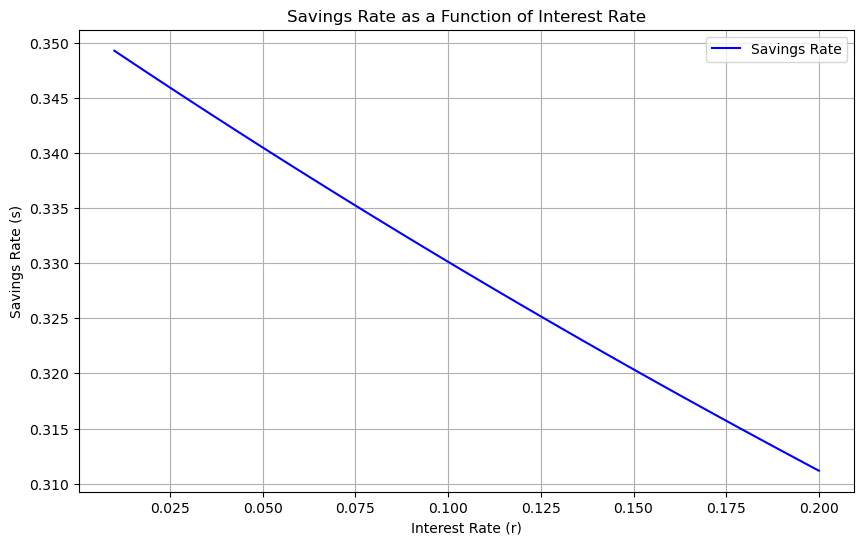

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Create a range of interest rates from 0.01 to 0.2
r_values = np.linspace(0.01, 0.2, 100)
s_values = [compute_savings_rate(rate, par) for rate in r_values]

plt.figure(figsize=(10, 6))
plt.plot(r_values, s_values, label='Savings Rate', color='blue')
plt.title('Savings Rate as a Function of Interest Rate')
plt.xlabel('Interest Rate (r)')
plt.ylabel('Savings Rate (s)')
plt.grid()
plt.legend()
plt.show()

##### Step 4: Compute excess capital demand

In [27]:
def compute_capital_ex_demand(k, par: Parameters):
    """
    Compute the excess demand for capital.

    Parameters
    ----------
    k : float
        Capital-labor ratio
    par : Parameters
        Parameters for the given problem

    Returns
    -------
    ex_demand : float
        Excess demand for capital
    """

    # TODO: Compute factor prices for given k and parameters
    r, w = compute_prices(k, par.z, par)
    # TODO: Compute savings rate for given r and parameters
    srate = compute_savings_rate(r, par)
    # TODO: Compute supply of capital from HH budget constraint
    A = srate * w * par.N
    # TODO: Compute demand for capital by firms
    L = par.N
    K = k * L
    # TODO: Compute and return excess demand for capital
    ex_demand = K - A
    
    return ex_demand

<div style="background-color: #c6dbef; color: #363636; padding: 0.8em 1em 0.5em 1em; border: 1pt solid #363636;">
<h3 style="font-weight: bold;">Your turn</h3>

Plot the function <tt>compute_capital_ex_demand()</tt> for <tt>k</tt> on the interval [0.01, 0.3] to verify that the function indeed has a root.

</div>
<span style="display: none;">YourTurnEnd</span>

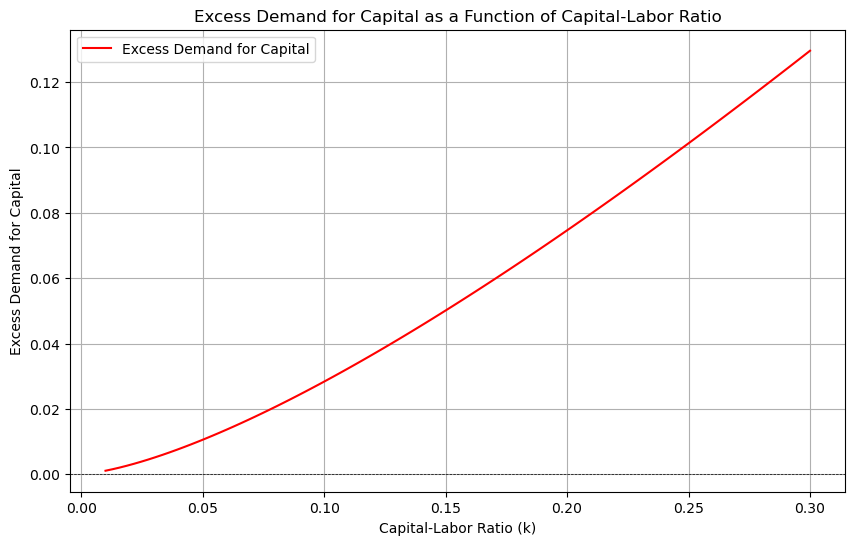

In [28]:
k = np.linspace(.01, .3, 100)
ex_demand_values = [compute_capital_ex_demand(k_i, par) for k_i in k]
plt.figure(figsize=(10, 6))
plt.plot(k, ex_demand_values, label='Excess Demand for Capital', color='red')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.title('Excess Demand for Capital as a Function of Capital-Labor Ratio')
plt.xlabel('Capital-Labor Ratio (k)')
plt.ylabel('Excess Demand for Capital')
plt.grid()
plt.legend()
plt.show()

##### Step 5: Call the root-finder

- Use 
[`root_scalar()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root_scalar.html)
- Use `method='brentq'` (the default) and specify initial bracket

In [29]:
from scipy.optimize import root_scalar

bracket = (1.0e-3, 1)

res = root_scalar(compute_capital_ex_demand, bracket=bracket, args=(par,))

res

ValueError: f(a) and f(b) must have different signs

##### Step 6: Compute remaining equilibrium quantities

- Store equilibrium quantities & prices in `SteadyState` instance

In [ ]:
@dataclass
class SteadyState:
    """
    Steady-state equilibrium of the OLG model.
    """
    par: Parameters = None      # Parameters used to compute equilibrium
    c_y: float = None           # Consumption when young
    c_o: float = None           # Consumption when old 
    a: float = None             # Savings when young
    s: float = None             # Savings rate when young    
    r: float = None             # Interest rate (return on capital)
    w: float = None             # Wage rate
    K: float = None             # Aggregate capital stock
    L: float = None             # Aggregate labor demand
    I: float = None             # Aggregate investment
    Y: float = None             # Aggregate output

- Write function `compute_steady_state()` to find equilibrium and compute remaining quantities & prices

In [ ]:
def compute_steady_state(par: Parameters):
    """
    Compute the steady-state equilibrium for the OLG model.

    Parameters
    ----------
    par : Parameters
        Parameters for the given problem

    Returns
    -------
    eq : SteadyState
        Steady state equilibrium of the OLG model
    """

    # TODO: Call root-finder
    # TODO: Create SteadyState instance to store results
    # TODO: Compute and store prices r, w
    # TODO: Compute and store HH variables c_y, c_o, a, s
    # TODO: Compute and store aggregate variables K, L, I, Y, C
    # TODO: Check goods market clearing

- Print equilibrium using `print_steady_state()` from [`lecture07_olg`](lecture07_olg.py) module

In [ ]:
# Import print_steady_state which is used to print the results in a nice format
from lecture07_olg import print_steady_state

# Compute equilibrium, return SteadyState instance 
eq = compute_steady_state(par)

# Print equilibrium allocation & prices
print_steady_state(eq)

<div style="background-color: #c6dbef; color: #363636; padding: 0.8em 1em 0.5em 1em; border: 1pt solid #363636;">
<h3 style="font-weight: bold;">Your turn</h3>

You are interested in how the equilibrium prices depend on the cohort size <i>N</i>. Plot the equilibrium prices <i>r</i> and <i>w</i> when varying <i>N</i> over the range of integers from 1 to 10.

</div>
<span style="display: none;">YourTurnEnd</span>

***
## Transition dynamics

- How does economy evolve after **unanticipated** shocks?
- Sequence of events:

    1.  Economy is in steady-state equilibrium
    2.  Economy is hit by a shock to TFP

        -   Examine permanent shock here, transitory/persistent shocks in workshop

    3.  Economy transitions to new steady state
    
-   Households have perfect foresight about evolution of all variables once shock is realized (full information rational expectations)



***
### Household problem ($N$ identical households)

- Households choose consumption & savings:
    $$
    \begin{aligned}
    \max_{c_{y,t},~c_{o,t+1},~a_t} \enskip & \Bigl\{ u(c_{y,t}) + \beta u(c_{o,t+1}) \Bigr\} \\
    \text{s.t.} \quad c_{y,t} + a_t &= w_t \\
                    c_{o,t+1} &= (1+r_{t+1})a_t \\
        c_{y,t} &\geq 0, ~ c_{o,t+1} \geq 0,~ a_t \geq 0 \enskip \text{for all } t
    \end{aligned}
    $$

-   Choice variables:

    -   $c_{y,t}$:  Consumption when young
    -   $c_{o,t+1}$:  Consumption when old
    -   $a_t$:    Savings when young

- Prices (taken as given, competitive equilibrium):

    -   $r_{t+1}$: Interest rate (return on capital) *next period*
    -   $w_t$: Wage rate

#### Analytical solution

-   General CRRA preferences:

    -   Savings rate depends on next-period $r_{t+1}$
        <a id='olg-trans-srate'></a>
        $$
        \tag{3}
        s_t = \left[ 1 + \beta^{-\frac{1}{\gamma}} (1+r_{t+1})^{1-\frac{1}{\gamma}}\right]^{-1}
        $$

    -   Next-period $r_{t+1}$ depends on savings rate $s_t$:
        $$
        r_{t+1} = \alpha z_{t+1} \left(\frac{K_{t+1}}{N}\right)^{\alpha-1}  - \delta = \alpha z_{t+1} \left( s_t  w_t \right)^{\alpha-1} - \delta
        $$

    -   **Is this a problem?**

-   Simplifying assumption: $\gamma = 1$
    $$
    s_t = \frac{\beta}{1+\beta}
    $$

-   See workshop exercise on how to obtain a solution with general CRRA preferences

***
### Equilibrium

Set of quantities $(K_t,L_t,Y_t,c_{o,t},c_{y,t},a_t)$ and prices $(r_t,w_t)$ such that:

- Asset market: $K_t = N a_{t-1}$
- Labor market: $L_t = N$
- Goods market: $Y_t + (1-\delta)K_t = N(c_{y,t} + c_{o,t} + a_t)$


***
### Transition path

Timeline of events:

- Period $t=0$: The economy is in the steady state with $K_0 = K^*$, $w_0 = w^*$, $a_0 = a^*$ etc.
- Period $t \geq 1$:
    -   The capital stock is pre-determined from the previous period, $K_t = N a_{t-1}$
    -   Production takes place:
        -   Young households earn $w_t = (1-\alpha) z_t (K_t / L)^{\alpha}$
        -   Old households earn gross asset returns $(1+r_t)a_{t-1}$ with $r_t = \alpha z_t (K_t / L)^{\alpha -1} - \delta$
    -   Consumption and savings:
        - Young households save $a_t = s w_t$ and consume $c_{y,t} = (1-s) w_t$
        - Old households consume $c_{o,t} = (1+r_t) a_{t-1}$


***
### Numerical implementation


1.  Define `Simulation` class to store simulation results
2.  Set model parameter & compute pre-shock steady state as starting point
3.  Implement function to perform simulation 
4.  Run simulation
5.  Plot simulated trajectories for selected variables

#### Step 1: `Simulation` class

In [ ]:
import numpy as np

@dataclass
class Simulation:
    c_y: np.ndarray = None      # Time series for consumption when young
    c_o: np.ndarray = None      # Time series for consumption when old 
    a: np.ndarray = None        # Time series for savings when young
    s: np.ndarray = None        # Time series for savings rate when young
    r: np.ndarray = None        # Time series for interest rate (return on capital)
    w: np.ndarray = None        # Time series for wages
    K: np.ndarray = None        # Time series for aggregate capital stock
    Y: np.ndarray = None        # Time series for aggregate output
    z: np.ndarray = None        # Time series for TFP
    

#### Step 2: Initial steady state

-   Need to use $\gamma = 1$
-   Use functions defined earlier to compute and report steady state

In [ ]:
# Parameter instance with risk aversion gamma=1
par = Parameters(gamma=1)

# Compute equilibrium at original TFP level
eq_init = compute_steady_state(par)

# Print initial equilibrium
print_steady_state(eq_init)  

#### Step 3: Implement simulation

In [ ]:
def simulate_olg(z_new, eq: SteadyState, T = 10):
    """
    Simulate the transition dynamics of the overlapping generations model.

    Parameters
    ----------
    z_new : float
        New level of TFP after the shock.
    eq : SteadyState
        Initial steady-state equilibrium before the shock.
    T : int
        Number of periods to simulate.

    Returns
    -------
    sim : Simulation
        Simulation object containing the time series for each variable.
    """

    # TODO:
    # 1. Make sure gamma = 1
    # 2. Initialize Simulation object
    # 3. Set TFP level and savings rate for all periods
    # 4. Loop through all periods t=1,...,T
    #     -   Compute K_t from previous period's savings
    #     -   Compute factor prices for given k and par
    #     -   Compute HH choices for given r, w and par
    #     -   Check goods market clearing

#### Step 4: Run simulation

In [ ]:
# Number of periods to simulate
T = 20

# New TFP level (10% drop from steady state)
z_new = 0.9 * par.z

# Perform simulation
sim = simulate_olg(z_new, eq_init, T=T)

#### Step 5: Plot simulation & new steady state

- Compute new steady state (where economy transitions to)

In [ ]:
# Compute new steady state using the NEW set of parameters
# eq_new = 

- Plot impulse-response functions (IRFs) for selected variables as % deviation from initial steady state

In [ ]:
from lecture07_olg import plot_simulation

# Plot impulse responses for selected variables
_ = plot_simulation(eq_init, sim, eq_new)

<div style="background-color: #c6dbef; color: #363636; padding: 0.8em 1em 0.5em 1em; border: 1pt solid #363636;">
<h3 style="font-weight: bold;">Your turn</h3>

As a robustness check, verify that the simulated trajectories are <i>constant</i> if the new TFP level is unchanged from the initial TFP level.

</div>
<span style="display: none;">YourTurnEnd</span>